### 1. Import the necessary libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline 
import seaborn as sns

 
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn import metrics
from sklearn.preprocessing import PowerTransformer
from sklearn.preprocessing import LabelEncoder

import warnings
warnings.filterwarnings('ignore')

In [2]:
# This is done to make Jupyter show all the columns. Otherwise Jupyter hides columns
pd.set_option('max_columns', None)

### 2. Import data 3Classdata.csv for 3 Class Classification.

In [3]:
missing_value_formats = ["n.a.","?","NA","n/a","na","--"," ","  "]
ThreeC_weka_data = pd.read_csv("3Classdata.csv", na_values = missing_value_formats)

### 3. Explore the dataset and mention the insights

#### Basic Statistical Analysis

In [81]:
ThreeC_weka_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 310 entries, 0 to 309
Data columns (total 7 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   pelvic_incidence          310 non-null    float64
 1   pelvic_tilt               310 non-null    float64
 2   lumbar_lordosis_angle     310 non-null    float64
 3   sacral_slope              310 non-null    float64
 4   pelvic_radius             310 non-null    float64
 5   degree_spondylolisthesis  310 non-null    float64
 6   class                     310 non-null    object 
dtypes: float64(6), object(1)
memory usage: 17.1+ KB


In [5]:
# There are 7 features, 6 numerical and one object

In [82]:
ThreeC_weka_data.describe()

,pelvic_incidence,pelvic_tilt,lumbar_lordosis_angle,sacral_slope,pelvic_radius,degree_spondylolisthesis
count,310.000000,310.000000,310.000000,310.000000,310.000000,310.000000
mean,60.496653,17.542822,51.930930,42.953831,117.920655,26.296694
std,17.236520,10.008330,18.554064,13.423102,13.317377,37.559027
min,26.147921,-6.554948,14.000000,13.366931,70.082575,-11.058179
25%,46.430294,10.667069,37.000000,33.347122,110.709196,1.603727
50%,58.691038,16.357689,49.562398,42.404912,118.268178,11.767934
75%,72.877696,22.120395,63.000000,52.695888,125.467674,41.287352
max,129.834041,49.431864,125.742385,121.429566,163.071041,418.543082


In [ ]:
# Same as 2Classdata, except "degree_spondylolisthesis", rest all of the columns have distribution close to normal. degree_spondylolisthesis seems to be
# right-tailed or positively skewed. 

In [4]:
ThreeC_weka_data.shape

(310, 7)

In [5]:
# The 3C_weka has 310 rows & 7 columns same as 2C_weka

In [6]:
# Checking top 5 rows
ThreeC_weka_data.head()

,pelvic_incidence,pelvic_tilt,lumbar_lordosis_angle,sacral_slope,pelvic_radius,degree_spondylolisthesis,class
0,63.027818,22.552586,39.609117,40.475232,98.672917,-0.254400,Hernia
1,39.056951,10.060991,25.015378,28.995960,114.405425,4.564259,Hernia
2,68.832021,22.218482,50.092194,46.613539,105.985135,-3.530317,Hernia
3,69.297008,24.652878,44.311238,44.644130,101.868495,11.211523,Hernia
4,49.712859,9.652075,28.317406,40.060784,108.168725,7.918501,Hernia


In [7]:
# Checking last 5 rows
ThreeC_weka_data.tail()

,pelvic_incidence,pelvic_tilt,lumbar_lordosis_angle,sacral_slope,pelvic_radius,degree_spondylolisthesis,class
305,47.903565,13.616688,36.000000,34.286877,117.449062,-4.245395,Normal
306,53.936748,20.721496,29.220534,33.215251,114.365845,-0.421010,Normal
307,61.446597,22.694968,46.170347,38.751628,125.670725,-2.707880,Normal
308,45.252792,8.693157,41.583126,36.559635,118.545842,0.214750,Normal
309,33.841641,5.073991,36.641233,28.767649,123.945244,-0.199249,Normal


In [9]:
# Checking for skewness
ThreeC_weka_data.skew()

pelvic_incidence            0.520440
pelvic_tilt                 0.676553
lumbar_lordosis_angle       0.599451
sacral_slope                0.792577
pelvic_radius              -0.176835
degree_spondylolisthesis    4.317954
dtype: float64

In [10]:
# As mentioned above "degree_spondylolisthesis" is positively skewed. 

In [11]:
# Checking for NA or Null values

In [83]:
ThreeC_weka_data.isna().sum()

pelvic_incidence            0
pelvic_tilt                 0
lumbar_lordosis_angle       0
sacral_slope                0
pelvic_radius               0
degree_spondylolisthesis    0
class                       0
dtype: int64

In [84]:
ThreeC_weka_data.isnull().sum()

pelvic_incidence            0
pelvic_tilt                 0
lumbar_lordosis_angle       0
sacral_slope                0
pelvic_radius               0
degree_spondylolisthesis    0
class                       0
dtype: int64

In [15]:
# There are no null values.

In [85]:
# Checking for duplicate data
ThreeC_weka_data.duplicated().sum()

0

In [17]:
# There is no duplicate data.

#### Univariate Analysis

In [20]:
# Checking for unique value count in target variable "class"

In [4]:
print(ThreeC_weka_data['class'].unique())

['Hernia' 'Spondylolisthesis' 'Normal']


In [23]:
# So, there are three classes 'Hernia', 'Spondylolisthesis', 'Normal'

In [24]:
# Count of each class

In [5]:
# Method 1
pd.crosstab(ThreeC_weka_data['class'],columns='Count')

col_0,Count
class,
Hernia,60
Normal,100
Spondylolisthesis,150


In [87]:
# Method 2
print(ThreeC_weka_data['class'].value_counts())

Spondylolisthesis    150
Normal               100
Hernia                60
Name: class, dtype: int64


<AxesSubplot:xlabel='class', ylabel='count'>

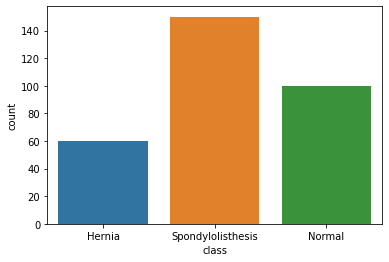

In [88]:
# Method 3
sns.countplot(x='class',data=ThreeC_weka_data)

In [6]:
# Identifying Type Of Features 
# Numerical Features & Categorical Features

numerical_features = ThreeC_weka_data.select_dtypes(include = [np.number])

In [7]:
print(numerical_features.columns)

Index(['pelvic_incidence', 'pelvic_tilt', 'lumbar_lordosis_angle',
       'sacral_slope', 'pelvic_radius', 'degree_spondylolisthesis'],
      dtype='object')


In [1]:
# Now we want to segregate discrete variables from continuous variables
# So, we count the number of unique values in each feature. If count of unique values is less than 25 then we consider it as
# discrete variable otherwise it is a continuous variable

In [8]:
continuous_numerical_features = []
discrete_numerical_features = []

In [9]:
for feature in numerical_features:
    if(len(ThreeC_weka_data[feature].unique())>25):
        continuous_numerical_features.append(feature)
        print('continuous_numerical_features ',feature)
   

continuous_numerical_features  pelvic_incidence
continuous_numerical_features  pelvic_tilt
continuous_numerical_features  lumbar_lordosis_angle
continuous_numerical_features  sacral_slope
continuous_numerical_features  pelvic_radius
continuous_numerical_features  degree_spondylolisthesis


In [93]:
# This shows that all the features are continuous 

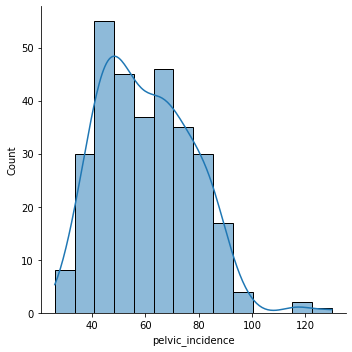

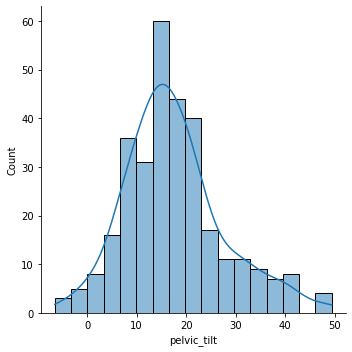

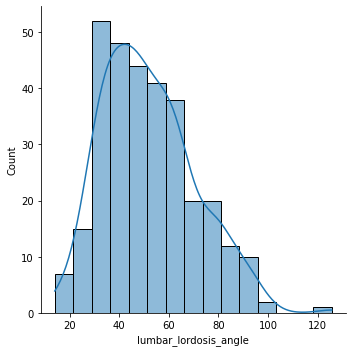

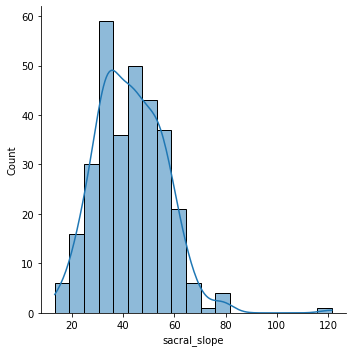

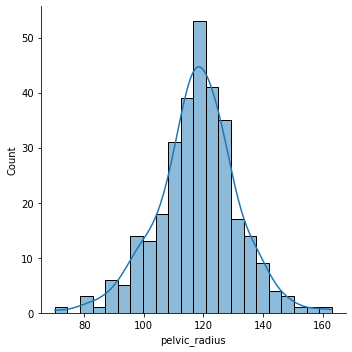

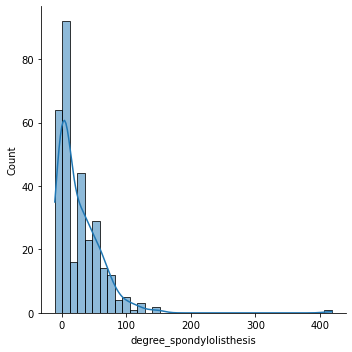

In [11]:
# Visualizing Distribution For Numerical Columns
# Not using distplot as it is going to be deprecated. See below link 
# https://seaborn.pydata.org/generated/seaborn.distplot.html?highlight=distplot#seaborn.distplot

for feature in numerical_features.columns:
    sns.displot(numerical_features[feature],kde=True)
    plt.show()

In [2]:
# Features "pelvic_tilt" & "pelvic_radius"  are very close to normal. 
# Features "pelvic_incidence", "lumbar_lordosis_angle" & "sacral_slope" have some kind of uniform distribution.
# Feature degree_spondylolisthesis is highly positively skewed.

In [96]:
# Now looking for IQR & Outliers

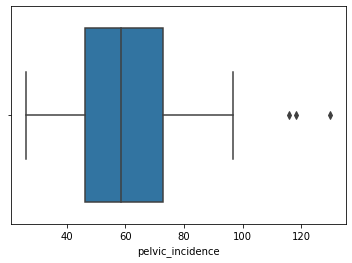

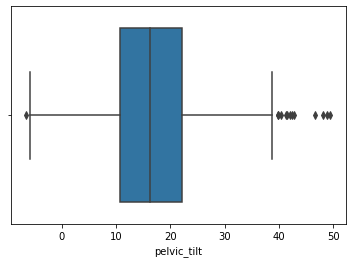

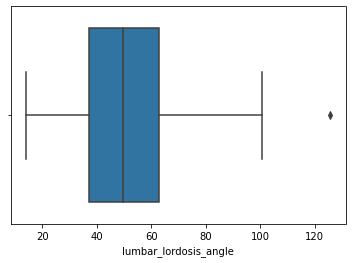

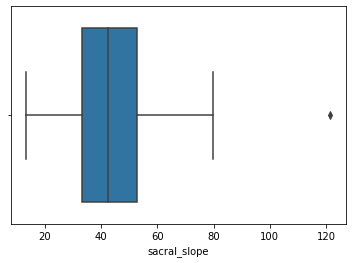

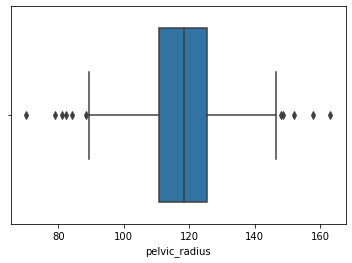

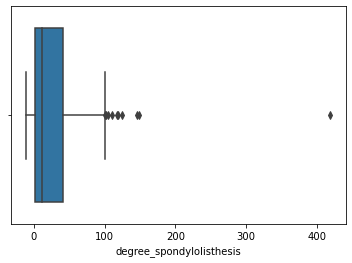

In [12]:
for feature in numerical_features.columns:
    sns.boxplot(ThreeC_weka_data[feature])
    plt.show()


In [113]:
# There are outliers in all of the features. Features "lumbar_lordosis_angle" & "sacral_slope" have just one outlier.
# Rest all have many outlies

#### Bivariate Analysis

<AxesSubplot:>

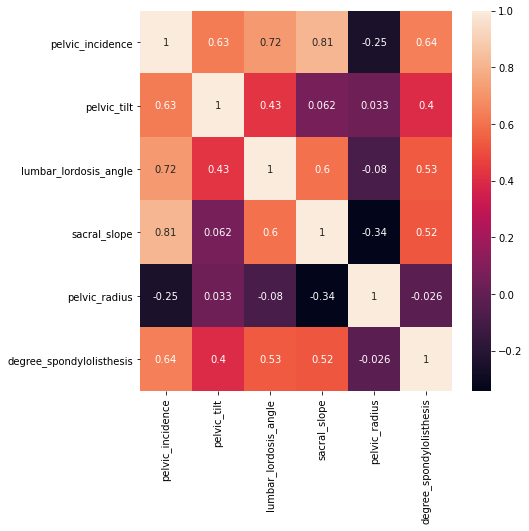

In [13]:
# Plotting Correlation HeatMap

plt.figure(figsize=(7,7))
sns.heatmap(ThreeC_weka_data.corr(),annot=True)

In [117]:
# It looks like there is some multicolinearity here. For example: Feature "pelvic_incidence" seems to be correlated with all the other features except "pelvic_radius".

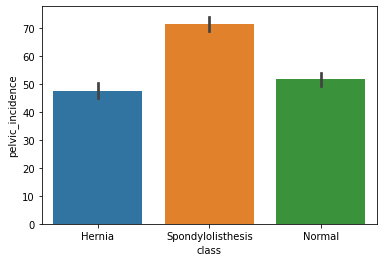

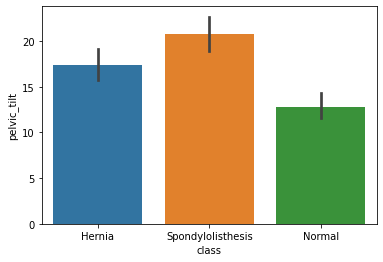

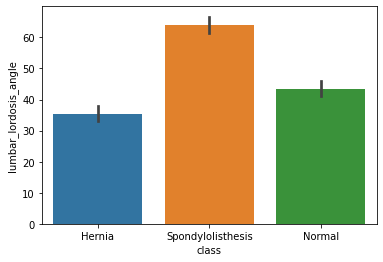

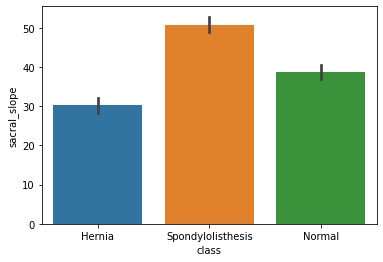

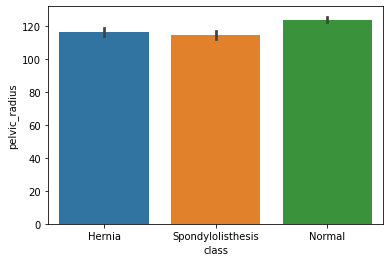

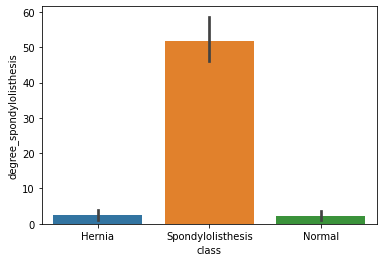

In [14]:
# Barplot showing the numbers 

for feature in numerical_features.columns:
    sns.barplot(x='class',y=feature,data=ThreeC_weka_data)
    plt.show()

In [119]:
# Class "Spondylolisthesis" has more count as compare to other two classes for alsmot all of the features

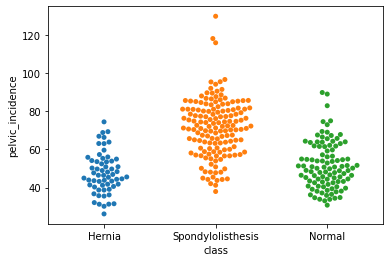

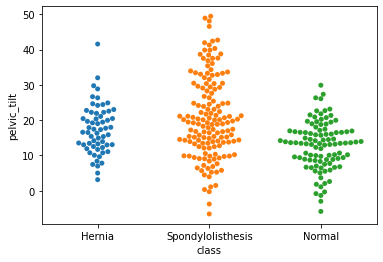

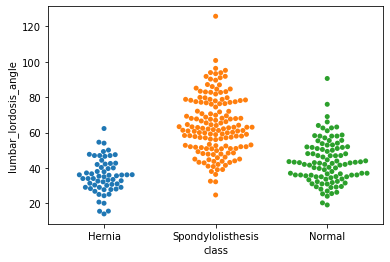

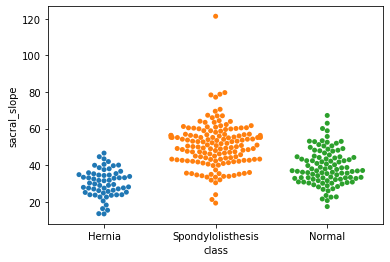

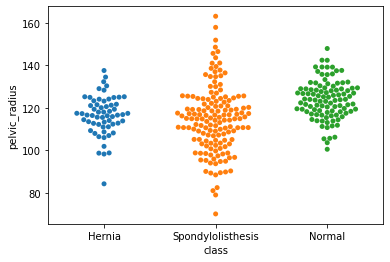

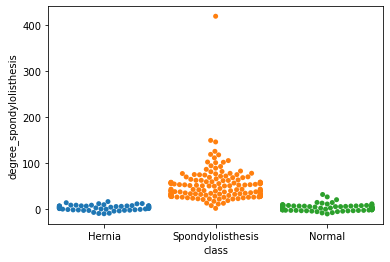

In [15]:
# Plotting Swarmplots

for feature in numerical_features.columns:
    sns.swarmplot(x=ThreeC_weka_data['class'],y=ThreeC_weka_data[feature])
    plt.show()

In [121]:
# Swarmplots showing spread as well as outliers.

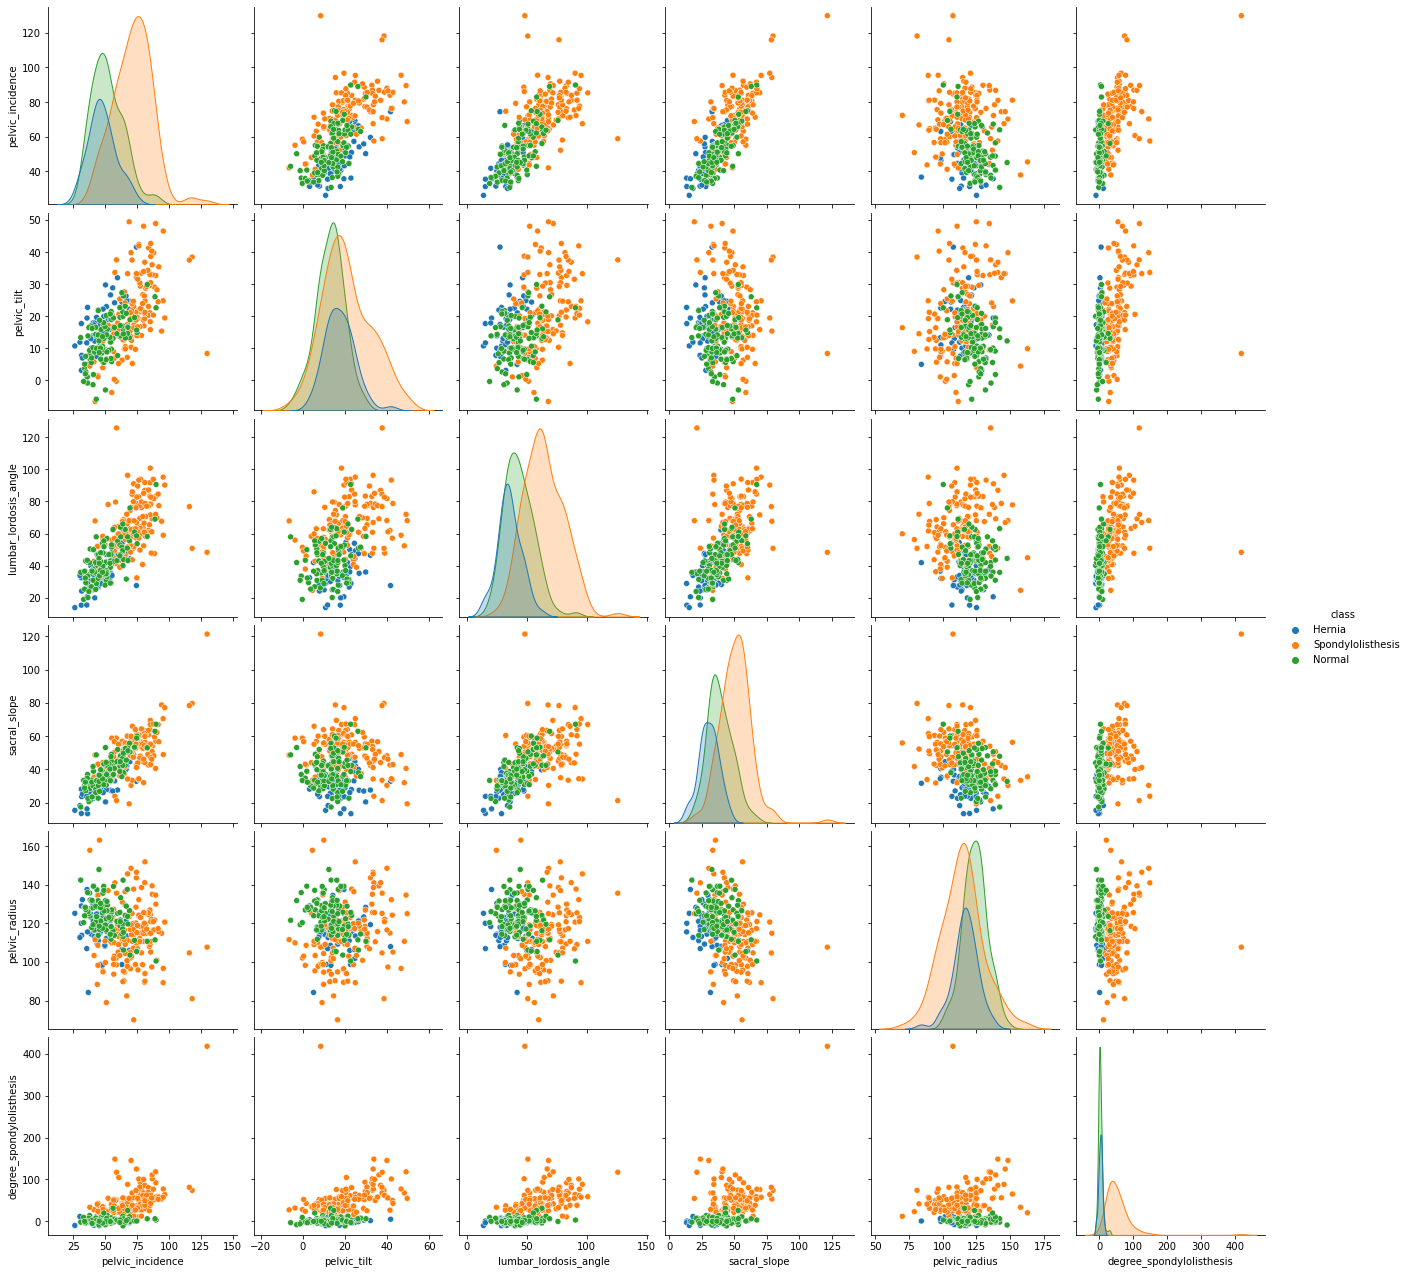

In [16]:
# Plotting pairplot

sns.pairplot(ThreeC_weka_data,size=3,hue='class')

In [126]:
# Features "pelvic_incidence", "lumbar_lordosis_angle" & "sacral_slope" looks to be good indicators as they have considerable separation. 
# It looks like feature "pelvic_incidence" has some degree of linear relationship with features "pelvic_tilt", "lumbar_lordosis_angle" & "sacral_slope". 
# Some other features also have linear relationship

In [10]:
# Fetching categorical variables
categorical_features = ThreeC_weka_data.select_dtypes(exclude = [np.number])

### 4. Encode the Class variable to integer

In [11]:
lbc = LabelEncoder()
ThreeC_weka_data_encoded = ThreeC_weka_data.copy()

In [12]:
for feature in categorical_features:
    ThreeC_weka_data_encoded[feature] =  lbc.fit_transform(ThreeC_weka_data[feature])

In [13]:
print(ThreeC_weka_data_encoded['class'].value_counts())

2    150
1    100
0     60
Name: class, dtype: int64


In [21]:
print(ThreeC_weka_data['class'].value_counts())

Spondylolisthesis    150
Normal               100
Hernia                60
Name: class, dtype: int64


In [ ]:
# I have used Scikit Learn's Label Encoder function above for the assignment purpose but the issue with it is, it encodes classes in "alphabetical order". 
# In our case, as you can see above, it encoded Hernia as 0 & Normal as 1 & Spondylolisthesis as 2 because "H" comes before "N" which comes before "S".   
# So, to get the desired encoding I can use simple pandas map function.

In [142]:
ThreeC_weka_data_encoded['class'] = ThreeC_weka_data_encoded['class'].map({'Normal':0, 'Hernia':1, 'Spondylolisthesis':2})

In [143]:
ThreeC_weka_data_encoded

,pelvic_incidence,pelvic_tilt,lumbar_lordosis_angle,sacral_slope,pelvic_radius,degree_spondylolisthesis,class
0,63.027818,22.552586,39.609117,40.475232,98.672917,-0.254400,1
1,39.056951,10.060991,25.015378,28.995960,114.405425,4.564259,1
2,68.832021,22.218482,50.092194,46.613539,105.985135,-3.530317,1
3,69.297008,24.652878,44.311238,44.644130,101.868495,11.211523,1
4,49.712859,9.652075,28.317406,40.060784,108.168725,7.918501,1
...,...,...,...,...,...,...,...
305,47.903565,13.616688,36.000000,34.286877,117.449062,-4.245395,0
306,53.936748,20.721496,29.220534,33.215251,114.365845,-0.421010,0
307,61.446597,22.694968,46.170347,38.751628,125.670725,-2.707880,0
308,45.252792,8.693157,41.583126,36.559635,118.545842,0.214750,0


In [144]:
ThreeC_weka_data_encoded['class'].value_counts()

2    150
0    100
1     60
Name: class, dtype: int64

In [ ]:
# So, we get the desired result

In [145]:
# Now, we got the desired encoding.
# But, I am not going to use this encoding either.
# Reason is, in classification report, I want to print "Hernia, Spondylolisthesis & Normal" instead of 0, 1 & 2 which is easy to understand. 

In [14]:
# Power Transformation is done to make data normal.
# Creating a dataset of numerical features only for transformation

numerical_dataset = ThreeC_weka_data_encoded.iloc[:,:6]
numerical_dataset

,pelvic_incidence,pelvic_tilt,lumbar_lordosis_angle,sacral_slope,pelvic_radius,degree_spondylolisthesis
0,63.027818,22.552586,39.609117,40.475232,98.672917,-0.254400
1,39.056951,10.060991,25.015378,28.995960,114.405425,4.564259
2,68.832021,22.218482,50.092194,46.613539,105.985135,-3.530317
3,69.297008,24.652878,44.311238,44.644130,101.868495,11.211523
4,49.712859,9.652075,28.317406,40.060784,108.168725,7.918501
...,...,...,...,...,...,...
305,47.903565,13.616688,36.000000,34.286877,117.449062,-4.245395
306,53.936748,20.721496,29.220534,33.215251,114.365845,-0.421010
307,61.446597,22.694968,46.170347,38.751628,125.670725,-2.707880
308,45.252792,8.693157,41.583126,36.559635,118.545842,0.214750


In [15]:
power_transform = PowerTransformer(method='yeo-johnson', standardize=True)

In [16]:
ThreeC_weka_data_transformed = power_transform.fit_transform(numerical_dataset)
ThreeC_weka_data_transformed = pd.DataFrame(ThreeC_weka_data_transformed,columns = numerical_dataset.columns)

             Original  pelvic_incidence


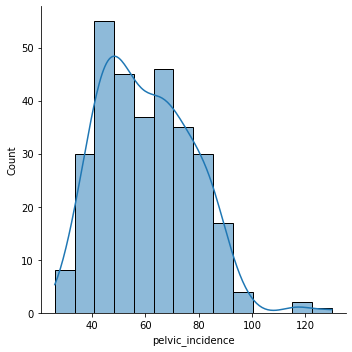

             Transformed  pelvic_incidence


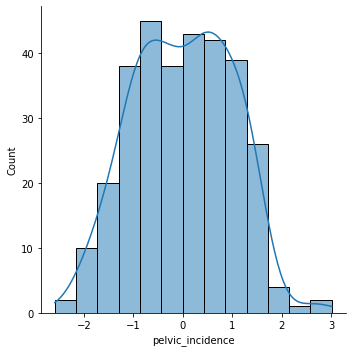

-----------------------------------------------------
             Original  pelvic_tilt


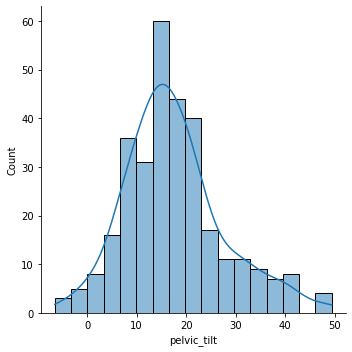

             Transformed  pelvic_tilt


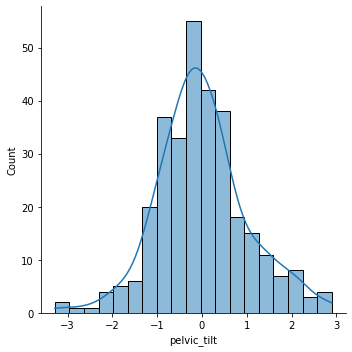

-----------------------------------------------------
             Original  lumbar_lordosis_angle


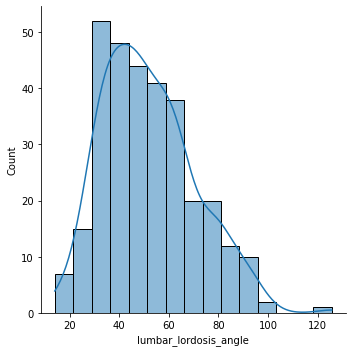

             Transformed  lumbar_lordosis_angle


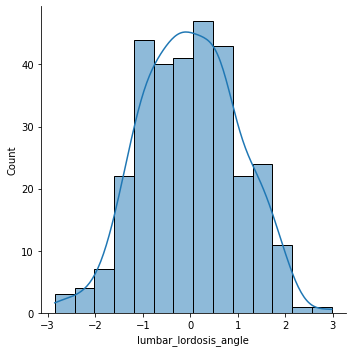

-----------------------------------------------------
             Original  sacral_slope


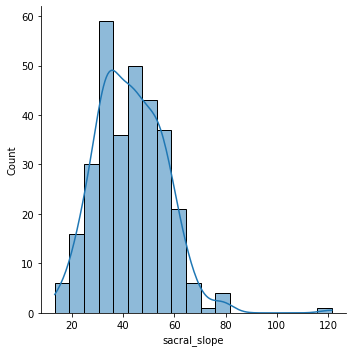

             Transformed  sacral_slope


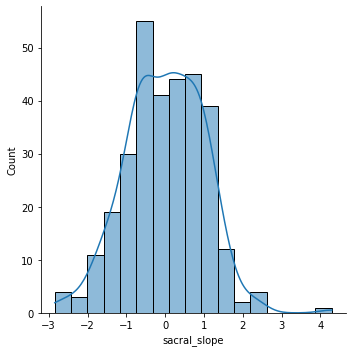

-----------------------------------------------------
             Original  pelvic_radius


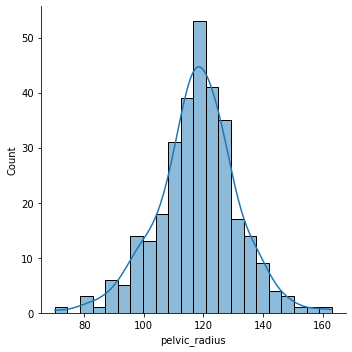

             Transformed  pelvic_radius


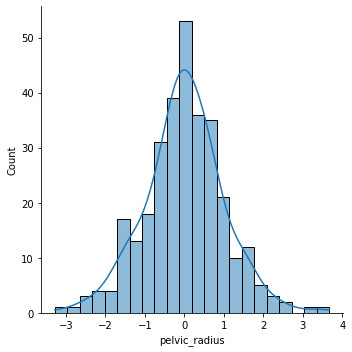

-----------------------------------------------------
             Original  degree_spondylolisthesis


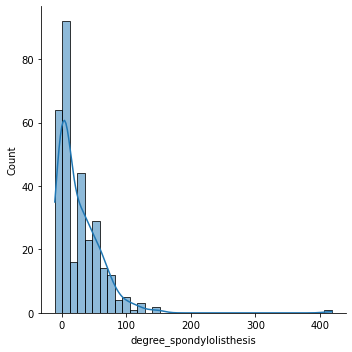

             Transformed  degree_spondylolisthesis


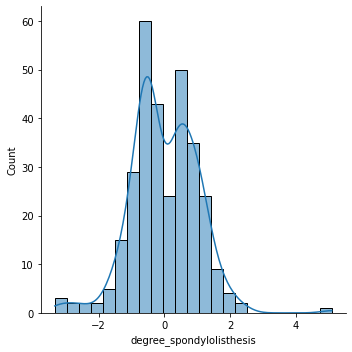

-----------------------------------------------------


In [77]:
# Distribution after transformation. 
# I have plotted both the original & transformed distribution for comparison.
# We can observe that features have been transformed into Normal distribution

for feature in ThreeC_weka_data_transformed.columns:
    print("             Original ", feature)
    sns.displot(numerical_features[feature],kde=True)
    plt.show()
    print("             Transformed ", feature)
    sns.displot(ThreeC_weka_data_transformed[feature],kde=True)
    plt.show()  
    print("-----------------------------------------------------")

In [78]:
# Same as 2C Data, this feature "degree_spondylolisthesis" shown above is not fully normal. It has two peaks. At this stage of this course, what I know is
# we separate these two peaks then we move forward. But we haven't completed such topic so far. So, I will keep this as it is.

### 5. Create the X(Feature-set) and Y(Target-set) sets for your Data

In [17]:
# Keeping X in uppercase & y in lowercase as per standard convention

X = ThreeC_weka_data_transformed
y = ThreeC_weka_data.iloc[:,6:]

### 7. Split the data as a train and test with a ratio of 70:30
### 6. Normalize your Data (X) to get values between 0 to 1
### 8. Train k-NN algorithm and optionally one other classification algorithm of your choice using the train data and measure their accuracy scores on the test data

#### Training KNN algorithm

In [20]:
# 8. Training KNN algorithm


# K-neighbours Classifier

# First Splitting the data set into train & test data set so that while scaling or normalizing, test data should not affect train data
# Second, different random states can give different results. So we need to test for multiple random states
# Third, for every random state, different value of k can give different results. So, we need to test for multiple values of k
# for each of the random state

# fit gives you mean and standard deviation
# So we do "fit" the model using train data and then "transform" or apply that mean & std on test data.

# Scaling should be done separately on train data & test data. Data leak issue occurs.
# It may show higher accuracy but might not be true
# Scaling or Normalization
# This is done to scale or normalize all the variable with different scales so that all these variable become comparable. 
# Compare Km/Hr to Mtr/Sec

# We check for multiple random state & for each random state, we check for multiple K values
# This is how we can come to a conclusion which random state and value of K is to be chosen
# We can also change the metric & weights as we find appropriate
# We can apply any condition we like


ran_state = np.arange(1,50)
neighbours = np.arange(5,41)
# I know that it is better to keep K-Value odd to have clear majority but I am not keeping it because I tried and I am getting much 
# better result with even numbers.

 
test_accuracy_list = []
train_accuracy_list = []
desired_k_value_list = []
desired_random_state_list = []
conf_matrix_report_list = []
class_report_list = []
 

for r_state in ran_state:
    # 7. Split the data as a train and test with a ratio of 70:30
    X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.3,random_state=r_state)
    
    std_scaler = StandardScaler() 
    # 6. Normalize your Data (X)
    std_scaler.fit(X_train)     
    X_train_scaled = std_scaler.transform(X_train)
    X_test_scaled  = std_scaler.transform(X_test)
    
    for k_value in neighbours:
        # For metric='minkowski' p=2 means using Euclidean distance &  p=1 means Manhattan distance 
        KNN = KNeighborsClassifier(n_neighbors=k_value,metric='minkowski',algorithm='auto',p=2) 
        
        KNN.fit(X_train_scaled,y_train)
        y_pred = KNN.predict(X_test_scaled)    
        
        conf_matrix = metrics.confusion_matrix(y_test,y_pred)
        class_report = metrics.classification_report(y_test,y_pred)
        train_score = np.round(KNN.score(X_train_scaled,y_train),2)
        test_score = np.round(KNN.score(X_test_scaled,y_test),2)
        test_accuracy_list.append(test_score)
        train_accuracy_list.append(train_score)
        desired_k_value_list.append(k_value)
        desired_random_state_list.append(r_state)
        conf_matrix_report_list.append(conf_matrix)
        class_report_list.append(class_report)

        
test_accuracy_array = np.array(test_accuracy_list)
result = np.where(test_accuracy_array>0.83)
result = result[0]

     # If a patient is predicted Normal when he has "Hernia" or "Spondylolisthesis", then this prediction is bad. Patient is having medical issue but model 
     # predicted patient does not have any issue. We definitely need to minimize this (False Negative) as much as possible. So, I have chosen to keep all incorrect 
     # predictions less than 5
    
for r in result:  
    conf = conf_matrix_report_list[r]
    if(conf[0,1]<5 and conf[0,2]<5 and conf[1,0]<5 and conf[1,2]<5 and conf[2,0]<5 and conf[2,1]<5):
        print('Test Accuracy',test_accuracy_list[r],'Train Accuracy',train_accuracy_list[r],'K Value ' ,desired_k_value_list[r],'Random State ',desired_random_state_list[r])
        print()
        print("Confusion Matrix ")
        print(conf_matrix_report_list[r])
        print()
        print("Classification Report ")
        print(class_report_list[r])
        print("--------------------------------------------------------")

        

Test Accuracy 0.86 Train Accuracy 0.81 K Value  20 Random State  4

Confusion Matrix 
[[13  4  0]
 [ 4 26  2]
 [ 1  2 41]]

Classification Report 
                   precision    recall  f1-score   support

           Hernia       0.72      0.76      0.74        17
           Normal       0.81      0.81      0.81        32
Spondylolisthesis       0.95      0.93      0.94        44

         accuracy                           0.86        93
        macro avg       0.83      0.84      0.83        93
     weighted avg       0.86      0.86      0.86        93

--------------------------------------------------------
Test Accuracy 0.86 Train Accuracy 0.82 K Value  5 Random State  10

Confusion Matrix 
[[12  4  0]
 [ 4 23  1]
 [ 4  0 45]]

Classification Report 
                   precision    recall  f1-score   support

           Hernia       0.60      0.75      0.67        16
           Normal       0.85      0.82      0.84        28
Spondylolisthesis       0.98      0.92      0.95       

### 9. What is the best K value for your classification? Find at which k value you get the best score

In [88]:
# Here, as per my understanding, keeping False Negative as much low as possible should be on priority keeping test accuracy high so, Random State 26 & K - Value = 18
# gives us overall test accuracy 86, precision for Hernia class is 80, for Spondylolisthesis is 96 & false negative are less as compare to others for KNN. 

#### Training Gaussian Naive Bayes

In [40]:
# Training Gaussian Naive Bayes

ran_state = np.arange(1,50)

test_accuracy_list = []
train_accuracy_list = []
desired_random_state_list = []
conf_matrix_report_list = []
class_report_list = []

for r_state in ran_state:
    GNB_X_train,GNB_X_test,GNB_y_train,GNB_y_test = train_test_split(X,y,test_size=0.3,random_state=r_state)
    
    gnb = GaussianNB()
    gnb.fit(GNB_X_train,GNB_y_train)
    GNB_y_pred = gnb.predict(GNB_X_test)
    
    conf_matrix = metrics.confusion_matrix(GNB_y_test,GNB_y_pred)
    class_report = metrics.classification_report(GNB_y_test,GNB_y_pred)
    test_score = np.round(gnb.score(GNB_X_test,GNB_y_test),2)
    train_score = np.round(gnb.score(GNB_X_train,GNB_y_train),2)
    test_accuracy_list.append(test_score)
    train_accuracy_list.append(train_score)   
    desired_random_state_list.append(r_state)
    conf_matrix_report_list.append(conf_matrix)
    class_report_list.append(class_report)
        
       
     # If a patient is predicted Normal when he has "Hernia" or "Spondylolisthesis", then this prediction is bad. Patient is having medical issue but model 
     # predicted patient does not have any issue. We definitely need to minimize this (False Negative) as much as possible. So, I have chosen to keep all incorrect 
     # predictions less than 6
        
test_accuracy_array = np.array(test_accuracy_list)
result = np.where(test_accuracy_array>0.80)
result = result[0]


for r in result:  
    conf = conf_matrix_report_list[r]
    if(conf[0,1]<6 and conf[0,2]<6 and conf[1,0]<6 and conf[1,2]<6 and conf[2,0]<6 and conf[2,1]<6):
        print('Test Accuracy',test_accuracy_list[r],'Train Accuracy',train_accuracy_list[r],'Random State ',desired_random_state_list[r])
        print()
        print("Confusion Matrix ")
        print(conf_matrix_report_list[r])
        print()
        print("Classification Report ")
        print(class_report_list[r])
        print("--------------------------------------------------------")

    


Test Accuracy 0.83 Train Accuracy 0.8 Random State  9

Confusion Matrix 
[[14  4  0]
 [ 5 14  2]
 [ 1  4 49]]

Classification Report 
                   precision    recall  f1-score   support

           Hernia       0.70      0.78      0.74        18
           Normal       0.64      0.67      0.65        21
Spondylolisthesis       0.96      0.91      0.93        54

         accuracy                           0.83        93
        macro avg       0.77      0.78      0.77        93
     weighted avg       0.84      0.83      0.83        93

--------------------------------------------------------
Test Accuracy 0.81 Train Accuracy 0.79 Random State  13

Confusion Matrix 
[[12  3  1]
 [ 5 20  4]
 [ 0  5 43]]

Classification Report 
                   precision    recall  f1-score   support

           Hernia       0.71      0.75      0.73        16
           Normal       0.71      0.69      0.70        29
Spondylolisthesis       0.90      0.90      0.90        48

         accuracy  

In [41]:
# Again, keeping False Negative as much low as possible should be on priority keeping test accuracy high so, Random State 48 gives us overall test accuracy 84,
# precision for Hernia class is 75, for Spondylolisthesis is 90 & false negative are less as compared to other vlues for Random State 

#### Training Logistic Regression

In [42]:
# Training Logistic Regression


ran_state = np.arange(1,50)

test_accuracy_list = []
train_accuracy_list = []
desired_random_state_list = []
conf_matrix_report_list = []
class_report_list = []


for r_state in ran_state:

    
    LR_X_train,LR_X_test,LR_y_train,LR_y_test = train_test_split(X,y,test_size=0.3,random_state=r_state)
    
    logistic_regression = LogisticRegression()
    logistic_regression.fit(LR_X_train,LR_y_train)
    LR_y_predict = logistic_regression.predict(LR_X_test)
    
    conf_matrix = metrics.confusion_matrix(LR_y_test,LR_y_predict)
    class_report = metrics.classification_report(LR_y_test,LR_y_predict)
    test_score = np.round(logistic_regression.score(LR_X_test,LR_y_test),2)
    train_score = np.round(logistic_regression.score(LR_X_train,LR_y_train),2)
    test_accuracy_list.append(test_score)
    train_accuracy_list.append(train_score)   
    desired_random_state_list.append(r_state)
    conf_matrix_report_list.append(conf_matrix)
    class_report_list.append(class_report)
        
       
     # If a patient is predicted Normal when he has "Hernia" or "Spondylolisthesis", then this prediction is bad. Patient is having medical issue but model 
     # predicted patient does not have any issue. We definitely need to minimize this (False Negative) as much as possible. So, I have chosen to keep all incorrect 
     # predictions less than 6
        
test_accuracy_array = np.array(test_accuracy_list)
result = np.where(test_accuracy_array>0.80)
result = result[0]
        
for r in result:  
    conf = conf_matrix_report_list[r]
    if(conf[0,1]<6 and conf[0,2]<6 and conf[1,0]<6 and conf[1,2]<6 and conf[2,0]<6 and conf[2,1]<6):
        print('Test Accuracy',test_accuracy_list[r],'Train Accuracy',train_accuracy_list[r],'Random State ',desired_random_state_list[r])
        print()
        print("Confusion Matrix ")
        print(conf_matrix_report_list[r])
        print()
        print("Classification Report ")
        print(class_report_list[r])
        print("--------------------------------------------------------")     


Test Accuracy 0.88 Train Accuracy 0.87 Random State  4

Confusion Matrix 
[[12  5  0]
 [ 4 28  0]
 [ 0  2 42]]

Classification Report 
                   precision    recall  f1-score   support

           Hernia       0.75      0.71      0.73        17
           Normal       0.80      0.88      0.84        32
Spondylolisthesis       1.00      0.95      0.98        44

         accuracy                           0.88        93
        macro avg       0.85      0.85      0.85        93
     weighted avg       0.89      0.88      0.88        93

--------------------------------------------------------
Test Accuracy 0.9 Train Accuracy 0.86 Random State  7

Confusion Matrix 
[[ 9  1  1]
 [ 4 27  3]
 [ 0  0 48]]

Classification Report 
                   precision    recall  f1-score   support

           Hernia       0.69      0.82      0.75        11
           Normal       0.96      0.79      0.87        34
Spondylolisthesis       0.92      1.00      0.96        48

         accuracy   

In [43]:
# For random state 4 & 13, we get 100% success rate for Spondylolisthesis  prediction. For random state 4, we also get 75% success for Hernia 
# Also for random state 7, we get overall test accuracy 90% 
# We are getting much more encouraging results with Logistic Regression as compared to KNN & Naive Bayes